In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, IntSlider
from IPython.display import display
import warnings, os, urllib.request, time

## Exercice 1 : Opérations matricielles

Matrice originale :
[[2. 1. 3.]
 [0. 4. 1.]
 [5. 2. 0.]]

Determinant : -59.0000
La matrice est INVERSIBLE (det != 0).

Matrice inverse :
[[ 0.03389831 -0.10169492  0.18644068]
 [-0.08474576  0.25423729  0.03389831]
 [ 0.33898305 -0.01694915 -0.13559322]]

Produit de la matrice et de son inverse (devrait être l'identité) :
[[ 1. -0.  0.]
 [ 0.  1.  0.]
 [ 0.  0.  1.]]


C:\Users\meles\AppData\Local\Temp\ipykernel_15440\4080076265.py:42: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
c:\Users\meles\Documents\TTA_DI_BootCamp_Gilles-Chris_MAKE\env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


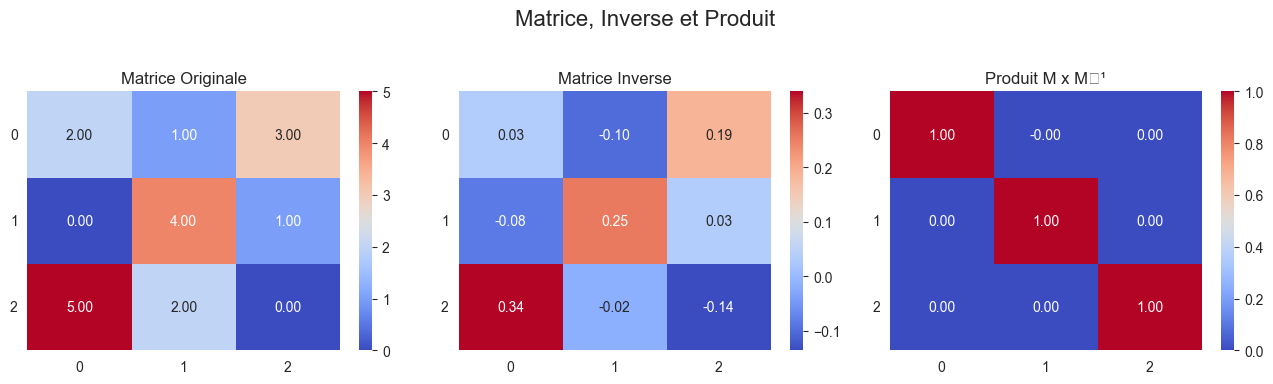

In [41]:
my_matrice = np.array([
    [2, 1, 3],
    [0, 4, 1],
    [5, 2, 0]
], dtype=float)

print("Matrice originale :")
print(my_matrice)

# Determinant de la matrice
det = np.linalg.det(my_matrice)
print(f"\nDeterminant : {det:.4f}")

if abs(det) < 1e-10:
    print("La matrice est SINGULIERE (non inversible).")
else:
    print("La matrice est INVERSIBLE (det != 0).")

# Inverse de la matrice
try:
    inverse = np.linalg.inv(my_matrice)
    print("\nMatrice inverse :")
    print(inverse)
except np.linalg.LinAlgError:
    print("\nImpossible de calculer l'inverse de la matrice.")

# Verification : M x M⁻¹ = Identite
product = np.round(np.dot(my_matrice, inverse), decimals=10)
print("\nProduit de la matrice et de son inverse (devrait être l'identité) :")
print(product)

#Visualisation de la matrice
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Matrice, Inverse et Produit", fontsize=16)

for ax, (mat, title) in zip(ax, [(my_matrice, "Matrice Originale"), (inverse, "Matrice Inverse"), (product, "Produit M x M⁻¹")]):
    sns.heatmap(mat, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Exercice 2 : Analyse statistique

Moyenne: 47.98, Médiane: 49.51, Écart-Type: 15.50


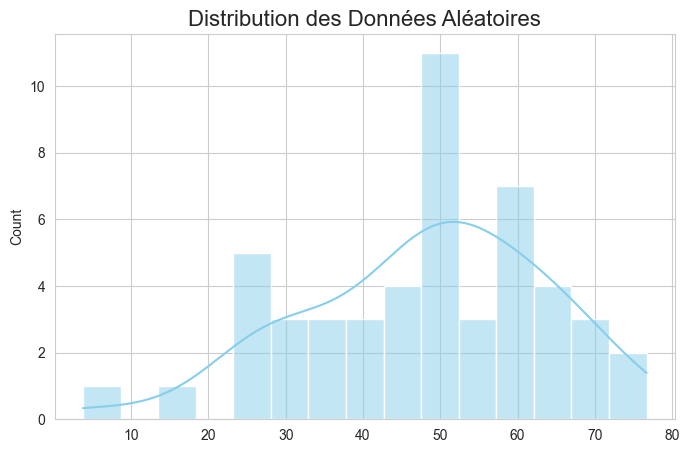

In [42]:
# Génération de données aléatoires pour la matrice
data = np.random.normal(loc=50, scale=15, size=50)

# Calculs statistiques
mean = np.mean(data)
median = np.median(data)
std_dev = np.std(data)
print(f"Moyenne: {mean:.2f}, Médiane: {median:.2f}, Écart-Type: {std_dev:.2f}")

# Visualisation de la distribution
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data, bins=15, kde=True, color='skyblue', ax=ax)
ax.set_title("Distribution des Données Aléatoires", fontsize=16)
plt.show()


## Exercice 3 : Manipulation des dates

In [43]:
dates_jan = np.arange('2023-01-01', '2023-02-01', dtype='datetime64[D]')

print("Dates de janvier 2023 :")
print(dates_jan)

# Conversion en format AAAA/MM/JJ
dates_formatted = np.array([str(d).replace('-', '/') for d in dates_jan])
print("\nDates converties en format AAAA/MM/JJ :")
print(dates_formatted)

Dates de janvier 2023 :
['2023-01-01' '2023-01-02' '2023-01-03' '2023-01-04' '2023-01-05'
 '2023-01-06' '2023-01-07' '2023-01-08' '2023-01-09' '2023-01-10'
 '2023-01-11' '2023-01-12' '2023-01-13' '2023-01-14' '2023-01-15'
 '2023-01-16' '2023-01-17' '2023-01-18' '2023-01-19' '2023-01-20'
 '2023-01-21' '2023-01-22' '2023-01-23' '2023-01-24' '2023-01-25'
 '2023-01-26' '2023-01-27' '2023-01-28' '2023-01-29' '2023-01-30'
 '2023-01-31']

Dates converties en format AAAA/MM/JJ :
['2023/01/01' '2023/01/02' '2023/01/03' '2023/01/04' '2023/01/05'
 '2023/01/06' '2023/01/07' '2023/01/08' '2023/01/09' '2023/01/10'
 '2023/01/11' '2023/01/12' '2023/01/13' '2023/01/14' '2023/01/15'
 '2023/01/16' '2023/01/17' '2023/01/18' '2023/01/19' '2023/01/20'
 '2023/01/21' '2023/01/22' '2023/01/23' '2023/01/24' '2023/01/25'
 '2023/01/26' '2023/01/27' '2023/01/28' '2023/01/29' '2023/01/30'
 '2023/01/31']


## Exercice 4 : Manipulation de données avec NumPy et Pandas

DataFrame initial :


,A,B,C,D,Categorie
0,44,47,64,67,X
1,67,9,83,21,Y
2,36,87,70,88,X
3,88,12,58,65,X
4,39,87,46,88,Y
5,81,37,25,77,Z



Lignes où A > 50 :


,A,B,C,D,Categorie
1,67,9,83,21,Y
3,88,12,58,65,X
5,81,37,25,77,Z



Lignes où B < 30 et C > 70 :


...

Categorie
X    56.0
Y    53.0
Z    81.0
Name: A, dtype: float64


Somme de B par catégorie :


Categorie
X    146
Y     96
Z     37
Name: B, dtype: int32


Nombre de lignes par catégorie :


Categorie
X    3
Y    2
Z    1
Name: count, dtype: int64

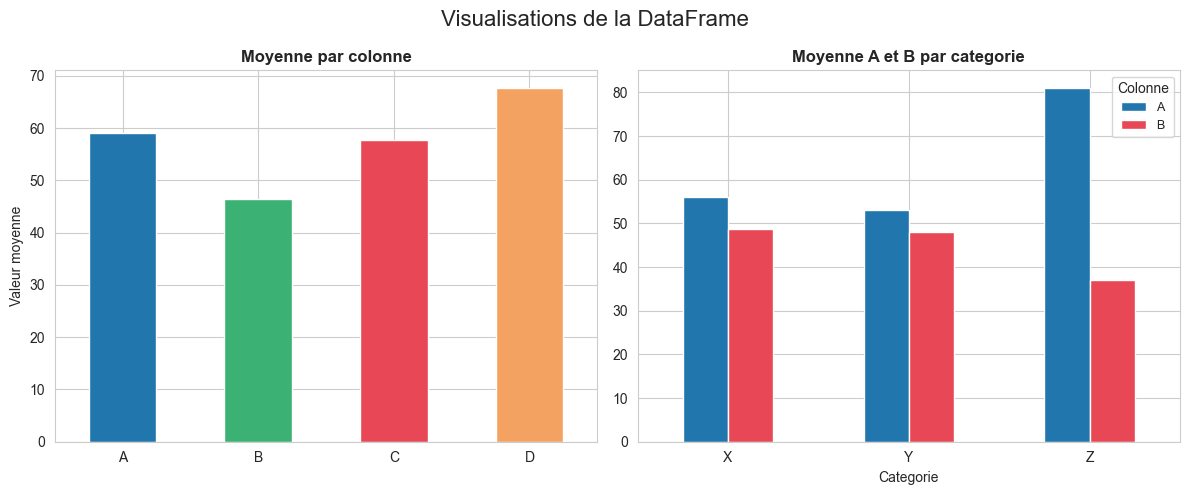

In [44]:
np.random.seed(0)
raw = np.random.randint(0, 100, size=(6, 4))
df = pd.DataFrame(raw, columns=['A', 'B', 'C', 'D'])
df['Categorie'] = np.random.choice(['X', 'Y', 'Z'], size=6)

print("DataFrame initial :")
display(df)

# Sélections conditionnelles
print("\nLignes où A > 50 :")
display(df[df['A'] > 50])
print("\nLignes où B < 30 et C > 70 :")
display(df[(df['B'] < 30) & (df['C'] > 70)])
print("\nLignes où la catégorie est 'Y' :")
display(df[df['Categorie'] == 'Y'])

# Agrégation
print("\nMoyenne de A par catégorie :")
display(df.groupby('Categorie')['A'].mean())
print("\nSomme de B par catégorie :")
display(df.groupby('Categorie')['B'].sum())
print("\nNombre de lignes par catégorie :")
display(df['Categorie'].value_counts())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Visualisations de la DataFrame", fontsize=16)
df[['A','B','C','D']].mean().plot(kind='bar', ax=axes[0],
                                   color=['#2176AE','#3BB273','#E84855','#F4A261'],
                                   edgecolor='white')
axes[0].set_title('Moyenne par colonne', fontweight='bold')
axes[0].set_ylabel('Valeur moyenne')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('Categorie')[['A','B']].mean().plot(kind='bar', ax=axes[1],
                                                 color=['#2176AE','#E84855'],
                                                 edgecolor='white')
axes[1].set_title('Moyenne A et B par categorie', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Colonne', fontsize=9)

plt.tight_layout()
plt.show()

## Exercice 5 : Représentation d'images

Image en niveaux de gris (5x5) :
[[  0  50 100 150 200]
 [ 50 100 150 200 255]
 [100 150 200 255 200]
 [150 200 255 200 150]
 [200 255 200 150 100]]

Valeurs de pixel :
Pixel (0,0): 0
Pixel (0,1): 50
Pixel (0,2): 100
Pixel (0,3): 150
Pixel (0,4): 200
Pixel (1,0): 50
Pixel (1,1): 100
Pixel (1,2): 150
Pixel (1,3): 200
Pixel (1,4): 255
Pixel (2,0): 100
Pixel (2,1): 150
Pixel (2,2): 200
Pixel (2,3): 255
Pixel (2,4): 200
Pixel (3,0): 150
Pixel (3,1): 200
Pixel (3,2): 255
Pixel (3,3): 200
Pixel (3,4): 150
Pixel (4,0): 200
Pixel (4,1): 255
Pixel (4,2): 200
Pixel (4,3): 150
Pixel (4,4): 100

Image RGB 5x5 : shape = (5, 5, 3)


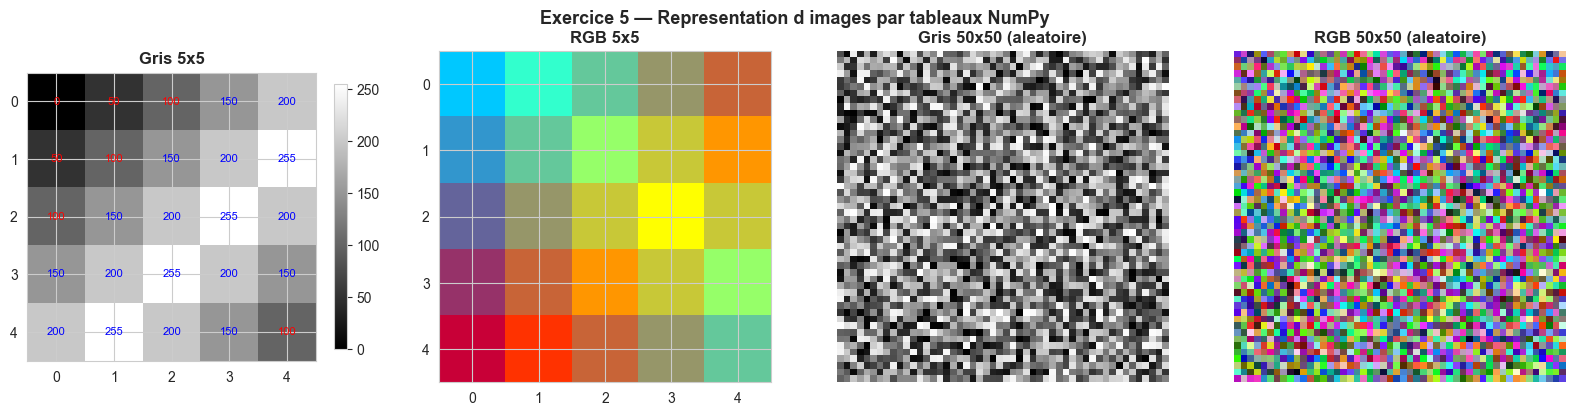

In [45]:
grayscale = np.array([
    [  0,  50, 100, 150, 200],
    [ 50, 100, 150, 200, 255],
    [100, 150, 200, 255, 200],
    [150, 200, 255, 200, 150],
    [200, 255, 200, 150, 100]
], dtype=np.uint8)

print("Image en niveaux de gris (5x5) :")
print(grayscale)
print("\nValeurs de pixel :")
for i in range(grayscale.shape[0]):
    for j in range(grayscale.shape[1]):
        print(f"Pixel ({i},{j}): {grayscale[i,j]}")

# Image en couleur (RGB)
rgb_image = np.zeros((5, 5, 3), dtype=np.uint8)
rgb_image[:, :, 0] = grayscale          # Canal Rouge
rgb_image[:, :, 1] = grayscale[::-1]    # Canal Vert (inverse)
rgb_image[:, :, 2] = 255 - grayscale    # Canal Bleu (complementaire)

print(f"\nImage RGB 5x5 : shape = {rgb_image.shape}")

# ── Image aleatoire plus grande ───────────────────────────────────────────────
big_gray  = np.random.randint(0, 256, (50, 50),    dtype=np.uint8)
big_color = np.random.randint(0, 256, (50, 50, 3), dtype=np.uint8)

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Exercice 5 — Representation d images par tableaux NumPy",
             fontsize=13, fontweight='bold')

# 5x5 gris
im0 = axes[0].imshow(grayscale, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Gris 5x5', fontweight='bold')
plt.colorbar(im0, ax=axes[0], shrink=0.8)
for i in range(5):
    for j in range(5):
        axes[0].text(j, i, str(grayscale[i,j]), ha='center', va='center',
                     fontsize=8, color='red' if grayscale[i,j] < 128 else 'blue')
axes[0].set_xticks(range(5)); axes[0].set_yticks(range(5))

# 5x5 RGB
axes[1].imshow(rgb_image)
axes[1].set_title('RGB 5x5', fontweight='bold')
axes[1].set_xticks(range(5)); axes[1].set_yticks(range(5))

# 50x50 gris aleatoire
axes[2].imshow(big_gray, cmap='gray')
axes[2].set_title('Gris 50x50 (aleatoire)', fontweight='bold')
axes[2].axis('off')

# 50x50 RGB aleatoire
axes[3].imshow(big_color)
axes[3].set_title('RGB 50x50 (aleatoire)', fontweight='bold')
axes[3].axis('off')

plt.tight_layout()
plt.show()

## Exercice 6 : Tests d'hypothèses de base

Donnees de productivite (30 employes)
  Avant  : moy=48.12  sigma=8.85
  Apres  : moy=52.76  sigma=9.52
  Diff   : moy=4.64  sigma=2.75

Test t appariele
  Statistique t  : 9.0915
  Valeur critique : 1.6991  (alpha=0.05, df=29)
  P-value        : 0.000000

  CONCLUSION : t (9.09) > t_critique (1.70)
  On REJETTE H0 : le programme ameliore significativement la productivite.

  IC 95% de la difference : [3.77, 5.50]
  -> 0 n est pas dans l intervalle => difference significative.


C:\Users\meles\AppData\Local\Temp\ipykernel_15440\1754098716.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Avant', 'Apres'])


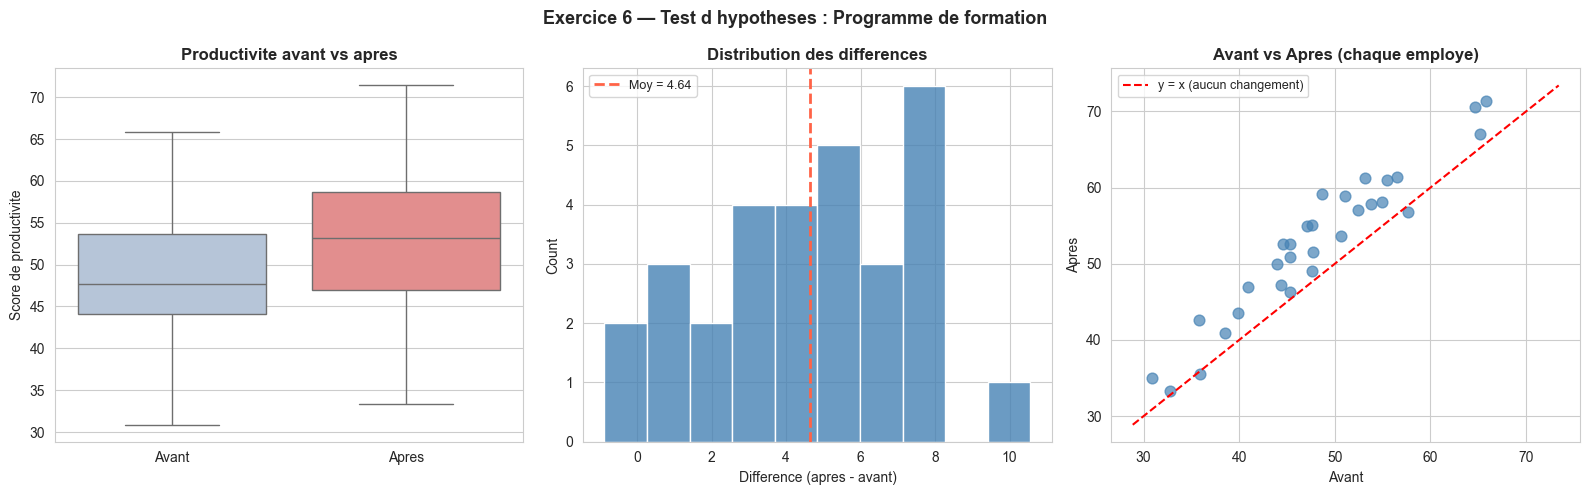

In [46]:
np.random.seed(42)

# Donnees 
productivity_before = np.random.normal(loc=50, scale=10, size=30)
productivity_after  = productivity_before + np.random.normal(loc=5, scale=3, size=30)

differences = productivity_after - productivity_before

print("Donnees de productivite (30 employes)")
print("=" * 50)
print(f"  Avant  : moy={np.mean(productivity_before):.2f}  sigma={np.std(productivity_before):.2f}")
print(f"  Apres  : moy={np.mean(productivity_after):.2f}  sigma={np.std(productivity_after):.2f}")
print(f"  Diff   : moy={np.mean(differences):.2f}  sigma={np.std(differences):.2f}")

# Test t appariele avec NumPy uniquement 
n     = len(differences)
t_val = np.mean(differences) / (np.std(differences, ddof=1) / np.sqrt(n))
alpha = 0.05

# Valeur critique (t a 29 degres de liberte, test unilateral)
from scipy.stats import t as t_dist, ttest_rel
t_critique = t_dist.ppf(1 - alpha, df=n-1)

# P-value via scipy pour comparaison
_, p_value = ttest_rel(productivity_after, productivity_before)

print(f"\nTest t appariele")
print(f"  Statistique t  : {t_val:.4f}")
print(f"  Valeur critique : {t_critique:.4f}  (alpha={alpha}, df={n-1})")
print(f"  P-value        : {p_value:.6f}")
print()
if t_val > t_critique:
    print(f"  CONCLUSION : t ({t_val:.2f}) > t_critique ({t_critique:.2f})")
    print("  On REJETTE H0 : le programme ameliore significativement la productivite.")
else:
    print("  On ne peut pas rejeter H0.")

# Intervalle de confiance a 95% 
ci_low  = np.mean(differences) - t_critique * (np.std(differences, ddof=1) / np.sqrt(n))
ci_high = np.mean(differences) + t_critique * (np.std(differences, ddof=1) / np.sqrt(n))
print(f"\n  IC 95% de la difference : [{ci_low:.2f}, {ci_high:.2f}]")
print("  -> 0 n est pas dans l intervalle => difference significative.")

#  Visualisation des resultats
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Exercice 6 — Test d hypotheses : Programme de formation", fontsize=13, fontweight='bold')

# Avant/apres
sns.boxplot(data=[productivity_before, productivity_after],
            palette=['lightsteelblue', 'lightcoral'],
            ax=axes[0])
axes[0].set_xticklabels(['Avant', 'Apres'])
axes[0].set_title('Productivite avant vs apres', fontweight='bold')
axes[0].set_ylabel('Score de productivite')

# Distribution des differences
sns.histplot(differences, bins=10, color='steelblue', edgecolor='white', alpha=0.8, ax=axes[1])
axes[1].axvline(np.mean(differences), color='tomato', linewidth=2, linestyle='--', label=f'Moy = {np.mean(differences):.2f}')
axes[1].set_title('Distribution des differences', fontweight='bold')
axes[1].set_xlabel('Difference (apres - avant)')
axes[1].legend(fontsize=9)

# Scatter avant vs apres
axes[2].scatter(productivity_before, productivity_after, color='steelblue', alpha=0.7, s=60)
lim_min = min(productivity_before.min(), productivity_after.min()) - 2
lim_max = max(productivity_before.max(), productivity_after.max()) + 2
axes[2].plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.5, label='y = x (aucun changement)')
axes[2].set_title('Avant vs Apres (chaque employe)', fontweight='bold')
axes[2].set_xlabel('Avant')
axes[2].set_ylabel('Apres')
axes[2].legend(fontsize=9)

# # Avant/apres
# axes[0].boxplot([productivity_before, productivity_after], patch_artist=True,
#                 labels=['Avant', 'Apres'],
#                 boxprops=dict(facecolor='lightsteelblue'),
#                 medianprops=dict(color='navy', linewidth=2.5))
# axes[0].set_title('Productivite avant vs apres', fontweight='bold')
# axes[0].set_ylabel('Score de productivite')

# # Distribution des differences
# axes[1].hist(differences, bins=10, color='steelblue', edgecolor='white', alpha=0.8)
# axes[1].axvline(np.mean(differences), color='tomato', linewidth=2,
#                 linestyle='--', label=f'Moy = {np.mean(differences):.2f}')
# axes[1].set_title('Distribution des differences', fontweight='bold')
# axes[1].set_xlabel('Difference (apres - avant)'); axes[1].legend(fontsize=9)

# # Scatter avant vs apres
# axes[2].scatter(productivity_before, productivity_after,
#                 color='steelblue', alpha=0.7, s=60)
# lim_min = min(productivity_before.min(), productivity_after.min()) - 2
# lim_max = max(productivity_before.max(), productivity_after.max()) + 2
# axes[2].plot([lim_min, lim_max], [lim_min, lim_max], 'r--',
#              linewidth=1.5, label='y = x (aucun changement)')
# axes[2].set_title('Avant vs Apres (chaque employe)', fontweight='bold')
# axes[2].set_xlabel('Avant'); axes[2].set_ylabel('Apres')
# axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()


## Exercice 7 : Comparaison de tableaux complexes

In [47]:
arr1 = np.array([5, 12, 3, 19, 7, 14, 2, 8])
arr2 = np.array([4, 15, 3, 10, 9,  7, 6, 8])

# Comparaisons 
superieur    = arr1 > arr2
inferieur    = arr1 < arr2
egal         = arr1 == arr2
superieur_ou = arr1 >= arr2

## Exercice 8 : Manipulation de données de séries temporelles

Serie temporelle 2023 : 365 jours
count    365.00
mean      58.98
std        5.32
min       46.29
25%       54.82
50%       59.00
75%       62.85
max       72.86
Name: Valeur, dtype: float64

Statistiques par trimestre :
Trimestre           Jours      Min      Max      Moy    Sigma
------------------------------------------------------------
  Q1 (Jan-Mar)         90    46.29    68.97    58.43     5.55
  Q2 (Avr-Jun)         91    55.70    71.55    63.19     3.29
  Q3 (Jul-Sep)         92    47.90    63.81    55.21     3.16
  Q4 (Oct-Dec)         92    47.01    72.86    59.13     5.47


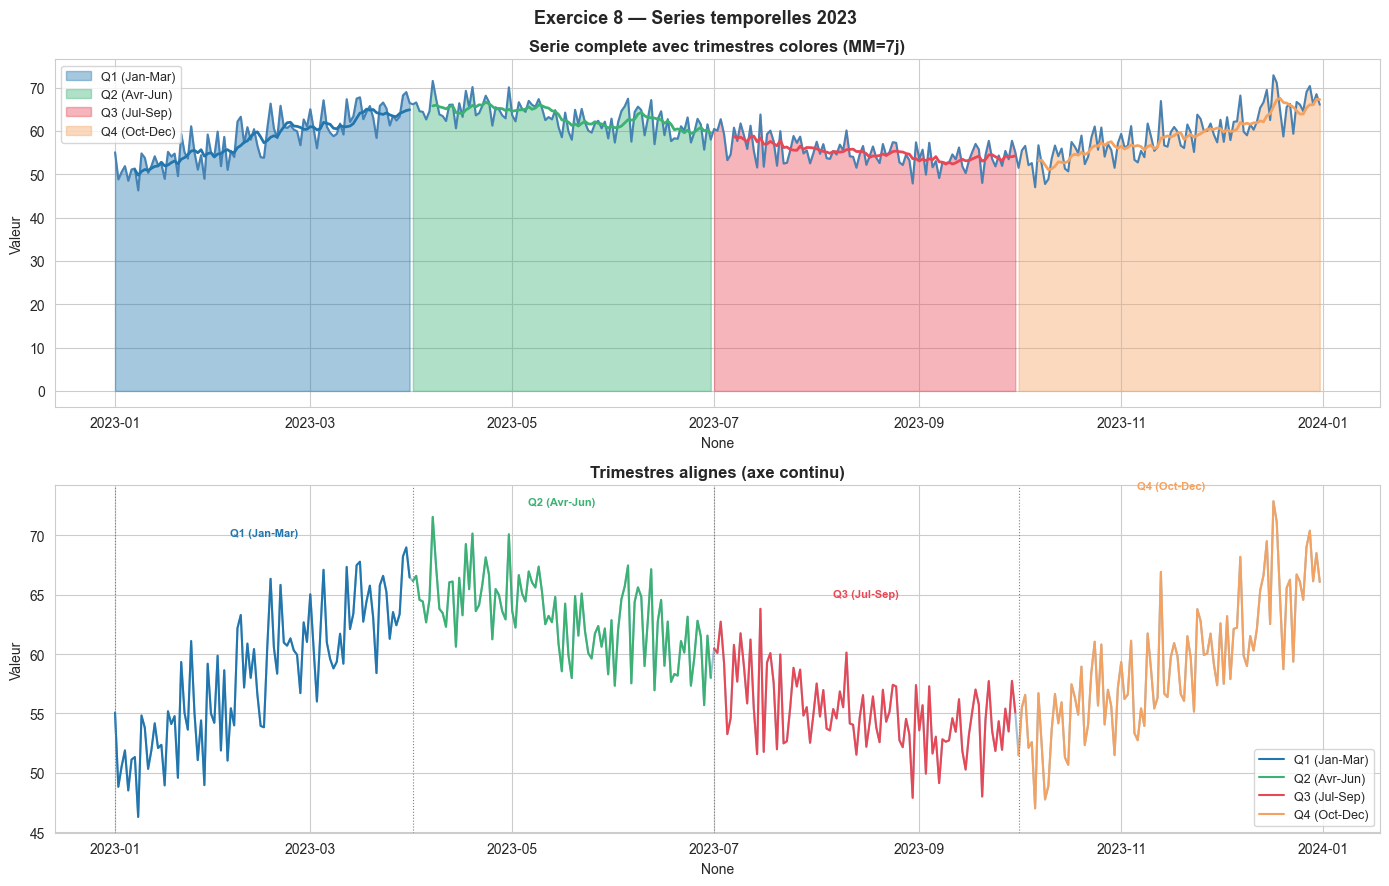

In [48]:
# Generation de la serie temporelle 2023 
dates_2023 = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')

# Donnees simulees : tendance + saisonnalite + bruit
np.random.seed(7)
n = len(dates_2023)
t = np.arange(n)
values = (50
          + 0.05 * t                              # tendance lineaire
          + 10 * np.sin(2 * np.pi * t / 365)     # saisonnalite annuelle
          + np.random.normal(0, 3, n))            # bruit

ts = pd.Series(values, index=dates_2023, name='Valeur')

print(f"Serie temporelle 2023 : {len(ts)} jours")
print(ts.describe().round(2))

#  Decoupage en 4 trimestres 
q1 = ts['2023-01-01':'2023-03-31']   # Janvier - Mars
q2 = ts['2023-04-01':'2023-06-30']   # Avril   - Juin
q3 = ts['2023-07-01':'2023-09-30']   # Juillet - Septembre
q4 = ts['2023-10-01':'2023-12-31']   # Octobre - Decembre

trimestres = {'Q1 (Jan-Mar)': q1, 'Q2 (Avr-Jun)': q2,
              'Q3 (Jul-Sep)': q3, 'Q4 (Oct-Dec)': q4}

print("\nStatistiques par trimestre :")
print(f"{'Trimestre':<18} {'Jours':>6} {'Min':>8} {'Max':>8} {'Moy':>8} {'Sigma':>8}")
print("-" * 60)
for name, q in trimestres.items():
    print(f"  {name:<16} {len(q):>6} {q.min():>8.2f} {q.max():>8.2f} {q.mean():>8.2f} {q.std():>8.2f}")

# Visualisation 
colors = ['#2176AE','#3BB273','#E84855','#F4A261']
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle("Exercice 8 — Series temporelles 2023", fontsize=13, fontweight='bold')

# Serie complete avec zones trimestrielles
sns.lineplot(x=ts.index, y=ts.values, color='steelblue', ax=axes[0])
for (name, q), color in zip(trimestres.items(), colors):
    axes[0].fill_between(q.index, q.values, alpha=0.4, color=color, label=name)
    axes[0].plot(q.index, q.rolling(7).mean(), color=color, linewidth=2)
axes[0].set_title('Serie complete avec trimestres colores (MM=7j)', fontweight='bold')
axes[0].set_ylabel('Valeur'); axes[0].legend(fontsize=9, loc='upper left')

# Trimestres en sous-graphiques
ax2 = axes[1]
offset = 0
sns.lineplot(x=ts.index, y=ts.values, color='steelblue', ax=ax2, alpha=0.5)
for (name, q), color in zip(trimestres.items(), colors):
    ax2.plot(q.index, q.values, color=color, linewidth=1.5, label=name)
    ax2.axvline(q.index[0], color='gray', linestyle=':', linewidth=0.8)
    ax2.text(q.index[len(q)//2], q.max() + 1, name,
             ha='center', fontsize=8, color=color, fontweight='bold')
    ax2.set_title('Trimestres alignes (axe continu)', fontweight='bold')
ax2.set_ylabel('Valeur'); ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()


## Exercice 9 : Conversion de données

In [49]:
#  NumPy -> Pandas 
print("NUMPY -> PANDAS")

# 2D : array -> DataFrame
array_2d = np.random.randint(1, 100, size=(4, 3))
df_from_np = pd.DataFrame(array_2d, columns=['X', 'Y', 'Z'])
print("\nArray NumPy 2D :")
print(array_2d)
print("DataFrame Pandas :")
display(df_from_np)

# 3D : array -> DataFrame
array_3d = np.random.randint(0, 50, size=(2, 3, 2))
df_3d = pd.DataFrame(
    array_3d.reshape(-1, array_3d.shape[-1]),
    columns=['Col1', 'Col2']
)
print(f"\nArray 3D {array_3d.shape} aplati en DataFrame {df_3d.shape} :")
display(df_3d)

# Pandas -> NumPy 
print("PANDAS -> NUMPY")

# DataFrame -> array
arr_from_df = df_from_np.to_numpy()
print("\nDataFrame -> Array :")
print(f"  {arr_from_df}  |  shape : {arr_from_df.shape}")


NUMPY -> PANDAS

Array NumPy 2D :
[[52  6 55]
 [36 80 41]
 [ 5 28  9]
 [66 21  3]]
DataFrame Pandas :


,X,Y,Z
0,52,6,55
1,36,80,41
2,5,28,9
3,66,21,3



Array 3D (2, 3, 2) aplati en DataFrame (6, 2) :


,Col1,Col2
0,46,43
1,13,8
2,21,11
3,0,10
4,41,49
5,33,27


PANDAS -> NUMPY

DataFrame -> Array :
  [[52  6 55]
 [36 80 41]
 [ 5 28  9]
 [66 21  3]]  |  shape : (4, 3)


## Exercice 10 : Visualisation de base

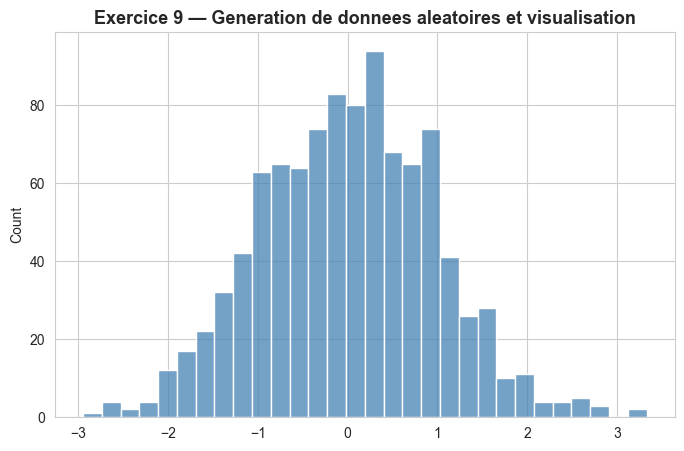

In [50]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(np.random.normal(0, 1, 1000), bins=30, color='steelblue', edgecolor='white', ax=ax)
ax.set_title("Exercice 9 — Generation de donnees aleatoires et visualisation", fontsize=13, fontweight='bold')
plt.show()